In [ ]:
🐶🐱 Cats vs Dogs Classification – HOG vs CNN
Dataset Includes:

HOG feature extraction
SVM training
Confusion matrix
ROC curve
CNN (ResNet18) feature extraction
Performance comparison

In [1]:
# Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

import seaborn as sns

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset


In [7]:
data_dir = "/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set"

import os
print(os.listdir(data_dir))

['dogs', 'cats']


In [ ]:
1️⃣ HOG Feature Extraction

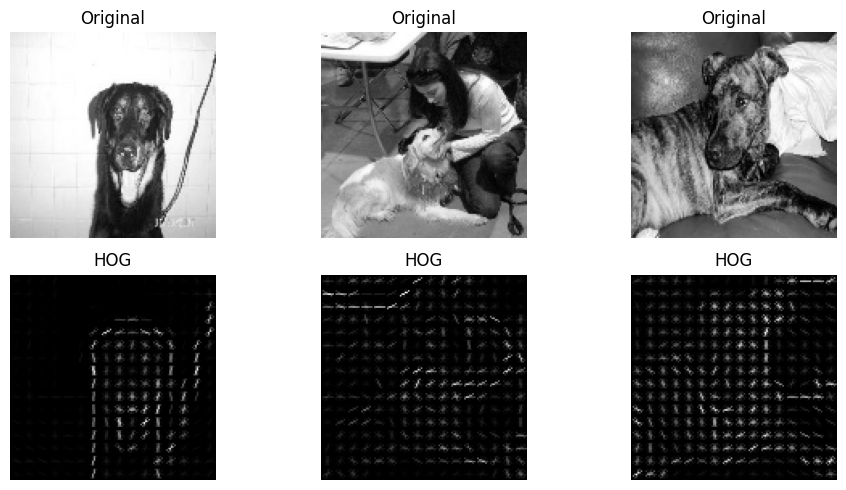

In [8]:
hog_features = []
hog_labels = []

plt.figure(figsize=(10,5))

display_count = 0
max_images = 500
count = 0

for label in os.listdir(data_dir):
    label_path = os.path.join(data_dir, label)

    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):
        if count >= max_images:
            break

        img_path = os.path.join(label_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (128,128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features, hog_img = hog(gray, orientations=9,
                                pixels_per_cell=(8,8),
                                cells_per_block=(2,2),
                                visualize=True)

        hog_features.append(features)
        hog_labels.append(label)

        if display_count < 3:
            plt.subplot(2,3,display_count+1)
            plt.imshow(gray, cmap='gray')
            plt.title('Original')
            plt.axis('off')

            plt.subplot(2,3,display_count+4)
            plt.imshow(hog_img, cmap='gray')
            plt.title('HOG')
            plt.axis('off')

            display_count += 1

        count += 1

plt.tight_layout()
plt.show()


In [9]:
# Save HOG Features
hog_df = pd.DataFrame(hog_features)
hog_df['label'] = hog_labels
hog_df.to_csv('hog_features.csv', index=False)
hog_df.head()


,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,label
0,0.186400,0.093137,0.198133,0.211291,0.271023,0.095732,0.086273,0.015955,0.000000,0.271023,...,0.260592,0.215533,0.177181,0.199488,0.141859,0.027079,0.039512,0.124386,0.026283,dogs
1,0.110837,0.013090,0.016856,0.037830,0.333636,0.001085,0.016991,0.048823,0.076733,0.087123,...,0.181025,0.224363,0.175063,0.093938,0.218818,0.144922,0.266331,0.266331,0.152969,dogs
2,0.106661,0.126494,0.227677,0.252138,0.252138,0.100873,0.181428,0.034006,0.055564,0.252138,...,0.095423,0.045836,0.230847,0.063479,0.261650,0.091664,0.097516,0.140629,0.152557,dogs
3,0.040671,0.008058,0.134494,0.142218,0.259772,0.232497,0.067908,0.003626,0.013051,0.089635,...,0.226995,0.228591,0.080135,0.000000,0.220609,0.123502,0.130806,0.132260,0.159959,dogs
4,0.195880,0.117583,0.095900,0.183467,0.248925,0.131963,0.125645,0.142591,0.034682,0.248925,...,0.220930,0.078127,0.075260,0.220930,0.220930,0.057563,0.094525,0.212036,0.119638,dogs


In [ ]:
Train SVM on HOG Features

In [13]:
X = hog_df.drop('label', axis=1).values
y = hog_df['label'].values

# check if dataset empty
print("Total samples:", len(X))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM model
svm_hog = SVC(kernel='rbf', probability=True)
svm_hog.fit(X_train, y_train)

# prediction
y_pred = svm_hog.predict(X_test)

print("HOG Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Total samples: 500


ValueError: The number of classes has to be greater than one; got 1 class

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - HOG')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# ROC Curve
y_prob = svm_hog.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve((y_test=='dogs').astype(int), y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()


In [ ]:
2️⃣ CNN Feature Extraction (ResNet18)

In [ ]:
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [ ]:
dataset = ImageFolder(data_dir, transform=transform)
dataset = Subset(dataset, range(500))

loader = DataLoader(dataset, batch_size=32, shuffle=False)


In [ ]:
cnn_features = []
cnn_labels = []

with torch.no_grad():
    for imgs, lbls in loader:
        output = model(imgs)
        output = output.view(output.size(0), -1)
        cnn_features.append(output.numpy())
        cnn_labels.append(lbls.numpy())

X_cnn = np.vstack(cnn_features)
y_cnn = np.hstack(cnn_labels)


In [ ]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42)

svm_cnn = SVC(kernel='rbf')
svm_cnn.fit(X_train_cnn, y_train_cnn)

y_pred_cnn = svm_cnn.predict(X_test_cnn)
print('CNN Feature Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))


In [ ]:
3️⃣ Performance Comparison

In [ ]:
print('HOG Accuracy:', accuracy_score(y_test, y_pred))
print('CNN Accuracy:', accuracy_score(y_test_cnn, y_pred_cnn))
